(convolution)=
# Convolutional predictive coding networks

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ComputationalPsychiatry/pyhgf/blob/master/docs/source/notebooks/0.6-Convolutional_networks.ipynb)


In [ ]:
import sys

from IPython.utils import io

if "google.colab" in sys.modules:
    with io.capture_output() as captured:
        get_ipython().system(' pip uninstall -y jax jaxlib')
        get_ipython().system(' pip install pyhgf watermark jax[cuda12]==0.4.31')

In [ ]:
import os
import pickle
import tarfile
import time
import urllib.request

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from pyhgf.model import (
    DeepNetwork,
    DeepNetworkAdapter,
    FusedPipeline,
    PCSequential,
    conv_block,
    flatten_adapter,
)
from pyhgf.plots.graphviz.plot_network import plot_deep_network

plt.rcParams["figure.constrained_layout.use"] = True

[Deep Bayesian predictive coding](0.5-Deep_learning.ipynb) showed that a `DeepNetwork` learns fully-connected layers with local, precision-weighted updates instead of backpropagation. A convolution is nothing more exotic than a *fully-connected layer shared across every spatial position of an image* — so the same machinery covers it, once the sharing is set up correctly.

This notebook builds that sharing from the ground up, trains it on two synthetic toy tasks, and finishes on real photographs (CIFAR-10). Throughout, we use the **hybrid pipeline** (`pyhgf.model.hybrid`/`pyhgf.model.fused`): a small set of frozen (weightless) *adapters* for the purely geometric parts of a convolution — extracting patches, pooling — wrapped around one small, genuinely learned `DeepNetwork` per convolutional layer. Pinning each layer's precision high and freezing its confidence updates (the same *backprop-parity recipe* used for the Transformer in earlier notebooks) makes each local update mathematically equal to a backpropagation step, by construction — so everything below trains with plain local belief updates, never an explicit gradient computation.

## From one shared layer to a convolution

A convolution kernel is a small weight matrix that is *reused* at every position it slides over: the same $3\times 3\times C_{in} \to C_{out}$ linear map, applied independently to every patch of the image. That reuse can be split into three independent pieces:

1. **Extract patches** (`im2col`) — turn every $k_h \times k_w$ neighbourhood of the image into one row of a table. This is a pure reshuffle of the input, with no weights at all.
2. **Apply one shared kernel** — a single small linear map (`out_channels ← in_channels·k_h·k_w`), applied identically to every row/patch. This is the *only* learned part.
3. **Pool** — locally summarise (average or take the max over) small neighbourhoods to shrink the spatial size before the next layer.

`pyhgf.model.conv` implements exactly this split:

- `im2col_adapter` / `avg_pool_adapter` / `max_pool_adapter` / `spatial_reshape_adapter` are **frozen** `EquinoxAdapter`s: closed-form forward and backward passes, no learned parameters, verified against `jax.vjp` in `tests/test_conv.py`.
- `conv_patch_network` builds the one learned piece — a tiny 2-layer `DeepNetwork`, the same object class used for any other fully-connected layer in this library.
- `conv_block` wires all of the above into a single `PCSequential`: `im2col → shared kernel (as a DeepNetworkAdapter) → GELU → reshape → pool`.

Before trusting that wiring, let's check it against a real convolution directly.

max abs difference vs. jax.lax.conv_general_dilated: 4.76837158203125e-07


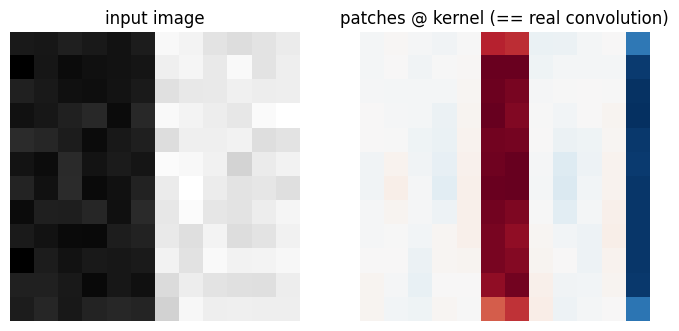

In [ ]:
from pyhgf.model import im2col_adapter, spatial_reshape_adapter

# A small synthetic image with a sharp vertical edge (bright on the right half).
size = 12
image = np.zeros((1, 1, size, size), dtype="float32")
image[0, 0, :, size // 2 :] = 1.0
image += np.random.default_rng(0).normal(scale=0.05, size=image.shape).astype("float32")

# A hand-set vertical-edge (Sobel-x) kernel -- no training involved yet.
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype="float32")
kernel = sobel_x[None, None, :, :]  # (out_channels=1, in_channels=1, kh=3, kw=3)

# Patch-extract by hand, then apply the shared kernel as one matrix product --
# this *is* what conv_block's im2col_adapter + DeepNetworkAdapter do internally.
patcher = im2col_adapter(filter_shape=(3, 3), strides=(1, 1), padding="SAME")
patches, _ = patcher.forward_fn(jnp.asarray(image))  # (1, n_patches, 9)
flat_kernel = kernel.reshape(1, -1)  # (out_channels, in_channels*kh*kw)
by_hand = patches @ flat_kernel.T  # (1, n_patches, 1)
by_hand = spatial_reshape_adapter(size, size).forward_fn(by_hand)[0]

# Ground truth: jax.lax's real convolution.
reference = jax.lax.conv_general_dilated(
    jnp.asarray(image), jnp.asarray(kernel), window_strides=(1, 1), padding="SAME",
    dimension_numbers=("NCHW", "OIHW", "NCHW"),
)

print("max abs difference vs. jax.lax.conv_general_dilated:",
      float(jnp.max(jnp.abs(by_hand - reference))))

fig, axs = plt.subplots(1, 2, figsize=(7, 3.2))
axs[0].imshow(image[0, 0], cmap="gray")
axs[0].set_title("input image")
axs[1].imshow(np.asarray(by_hand)[0, 0], cmap="RdBu_r")
axs[1].set_title("patches @ kernel (== real convolution)")
for ax in axs:
    ax.axis("off")

`im2col_adapter`'s patch table, multiplied by the flattened kernel, reproduces `jax.lax.conv_general_dilated` to floating-point precision — the two panels above show the same computation, one done "by hand" and one by JAX's own convolution primitive. `conv_block` replaces the hand-written matrix product with a `DeepNetworkAdapter` wrapping a trainable `conv_patch_network` (plus a GELU activation and a pooling step), so the kernel above becomes *learned* rather than hand-set — everything else about the wiring stays identical.

conv_block parts: ['EquinoxAdapter', 'DeepNetworkAdapter', 'EquinoxAdapter', 'EquinoxAdapter', 'EquinoxAdapter']
output shape (channels, height, width): (4, 6, 6)


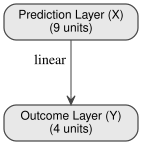

In [ ]:
part, out_shape = conv_block(
    in_channels=1, out_channels=4, in_height=size, in_width=size,
    filter_shape=(3, 3), padding="SAME", pool_kind="max", key=jax.random.key(0),
)
print("conv_block parts:", [type(p).__name__ for p in part.parts])
print("output shape (channels, height, width):", out_shape)

# The one learned piece is a plain DeepNetwork -- the same class used for any
# fully-connected layer in this library.
kernel_net = part.parts[1].net
plot_deep_network(kernel_net, view=False)

Two layers: the top one holds the flattened patch (`in_channels·k_h·k_w` nodes), the bottom one the output feature map (`out_channels` nodes) — exactly `conv_patch_network`'s docstring description, and small enough that training it costs about as much as training any other 2-layer `DeepNetwork`, no matter how large the image it gets applied to.

## A reusable training recipe

Every example below follows the same shape: stack one or more `conv_block`s, flatten the final feature map, and finish with a small `DeepNetwork` classifier whose bottom layer is `kind="categorical"` (a softmax over the class logits — see [Deep Bayesian predictive coding](0.5-Deep_learning.ipynb) for why a categorical layer's prediction error is exactly the cross-entropy gradient). `PARITY`/`PARITY_LEAF` are the backprop-parity settings mentioned in the introduction: high, effectively-fixed precision and no volatility parent, so each local update matches what backpropagation would compute for the same architecture.

In [ ]:
PARITY = dict(volatility_parent=False, precision=1e4, expected_precision=1e4)
PARITY_LEAF = dict(volatility_parent=False)


def build_conv_classifier(conv_channels, in_channels, in_hw, n_classes, hidden=32,
                           lr=1e-3, pool_kind="max", key=None):
    # Stack one conv_block per entry in conv_channels, then a small categorical classifier.
    key = jax.random.key(0) if key is None else key
    keys = list(jax.random.split(key, len(conv_channels) + 1))

    parts, c, h, w = [], in_channels, in_hw, in_hw
    for out_c, k in zip(conv_channels, keys[:-1]):
        block, (c, h, w) = conv_block(
            c, out_c, h, w, filter_shape=(3, 3), padding="SAME", pool_kind=pool_kind,
            optimizer=optax.adam(lr), key=k, leaf_kwargs=PARITY_LEAF, layer_kwargs=PARITY,
        )
        parts.append(block)

    classifier_net = (
        DeepNetwork()
        .add_layer(size=n_classes, kind="categorical", add_constant_input=False, **PARITY_LEAF)
        .add_layer(size=hidden, add_constant_input=False, coupling_fn=jax.nn.gelu, **PARITY)
        .add_layer(size=c * h * w, add_constant_input=False, **PARITY)
    ).weight_initialisation("he", key=keys[-1])
    classifier = DeepNetworkAdapter(
        classifier_net, optimizer=optax.adam(lr), learning_kind="precision_weighted",
    )
    parts += [flatten_adapter(c, h, w), classifier]

    fused = FusedPipeline(
        PCSequential(parts), error_fn=lambda probs, ids: probs - jax.nn.one_hot(ids, n_classes)
    )
    return fused, (c, h, w)


def evaluate(fused, X, y, batch=500):
    correct, n = 0, len(X)
    for start in range(0, n, batch):
        probs = np.asarray(fused.predict(jnp.asarray(X[start : start + batch])))
        correct += int(np.sum(probs.argmax(-1) == np.asarray(y[start : start + batch])))
    return correct / n


def train_classifier(fused, X_tr, y_tr, X_te, y_te, epochs, batch_size, seed=0, log_every=1):
    rng = np.random.default_rng(seed)
    n = len(X_tr)
    history = {"train_loss": [], "train_acc": [], "test_acc": []}
    for epoch in range(epochs):
        perm = rng.permutation(n)
        X_epoch, y_epoch = X_tr[perm], y_tr[perm]
        losses, correct, seen = [], 0, 0
        for start in range(0, n - batch_size + 1, batch_size):
            xb = jnp.asarray(X_epoch[start : start + batch_size])
            yb = jnp.asarray(y_epoch[start : start + batch_size])
            probs, _ = fused.step(xb, yb)
            probs = np.asarray(probs)
            p_true = probs[np.arange(len(yb)), np.asarray(yb)]
            losses.append(float(-np.mean(np.log(np.clip(p_true, 1e-7, 1.0)))))
            correct += int(np.sum(probs.argmax(-1) == np.asarray(yb)))
            seen += len(yb)
        test_acc = evaluate(fused, X_te, y_te)
        history["train_loss"].append(float(np.mean(losses)))
        history["train_acc"].append(correct / seen)
        history["test_acc"].append(test_acc)
        if epoch % log_every == 0 or epoch == epochs - 1:
            print(f"epoch {epoch:3d} | train loss {history['train_loss'][-1]:.3f} "
                  f"acc {history['train_acc'][-1]:.3f} | test acc {test_acc:.3f}")
    return history


def plot_history(history, title):
    deep = sns.color_palette("deep")
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
    axs[0].plot(history["train_loss"], color=deep[0])
    axs[0].set(xlabel="epoch", ylabel="cross-entropy", title=f"{title} — training loss")
    axs[1].plot(history["train_acc"], label="train", color=deep[0])
    axs[1].plot(history["test_acc"], label="test", color=deep[3])
    axs[1].set(xlabel="epoch", ylabel="accuracy", title=f"{title} — accuracy")
    axs[1].legend()
    sns.despine()

## Toy example 1: horizontal vs. vertical stripes

The simplest possible spatial-pattern task: single-channel $16\times 16$ images containing either horizontal or vertical stripes, buried in noise. One `conv_block` (1 input channel → 4 feature maps) followed by the classifier above is enough.

train: 480  test: 120


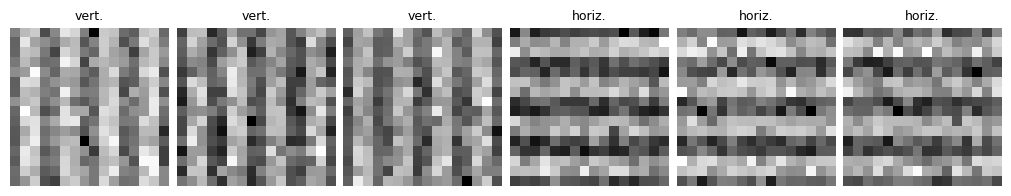

In [ ]:
def make_stripes(n_samples=600, size=16, period=4, noise=0.35, seed=0):
    rng = np.random.default_rng(seed)
    labels = rng.integers(0, 2, size=n_samples)  # 0 = horizontal, 1 = vertical
    base = (np.sin(2 * np.pi * np.arange(size) / period) > 0).astype("float32")
    images = np.empty((n_samples, 1, size, size), dtype="float32")
    for i, cls in enumerate(labels):
        images[i, 0] = np.tile(base[:, None], (1, size)) if cls == 0 else np.tile(base[None, :], (size, 1))
    images += rng.normal(scale=noise, size=images.shape).astype("float32")
    return images, labels.astype("int64")


X_stripes, y_stripes = make_stripes()
n_train = int(0.8 * len(X_stripes))
X_tr_s, X_te_s = X_stripes[:n_train], X_stripes[n_train:]
y_tr_s, y_te_s = y_stripes[:n_train], y_stripes[n_train:]

fig, axs = plt.subplots(1, 6, figsize=(10, 2))
for ax, img, label in zip(axs, X_stripes[:6], y_stripes[:6]):
    ax.imshow(img[0], cmap="gray")
    ax.set_title("horiz." if label == 0 else "vert.", fontsize=9)
    ax.axis("off")
print(f"train: {len(X_tr_s)}  test: {len(X_te_s)}")

feature map before the classifier: (4, 8, 8)


epoch   0 | train loss 0.825 acc 0.623 | test acc 0.800
epoch   2 | train loss 0.231 acc 1.000 | test acc 1.000
epoch   4 | train loss 0.052 acc 1.000 | test acc 1.000
epoch   6 | train loss 0.018 acc 1.000 | test acc 1.000
epoch   7 | train loss 0.013 acc 1.000 | test acc 1.000


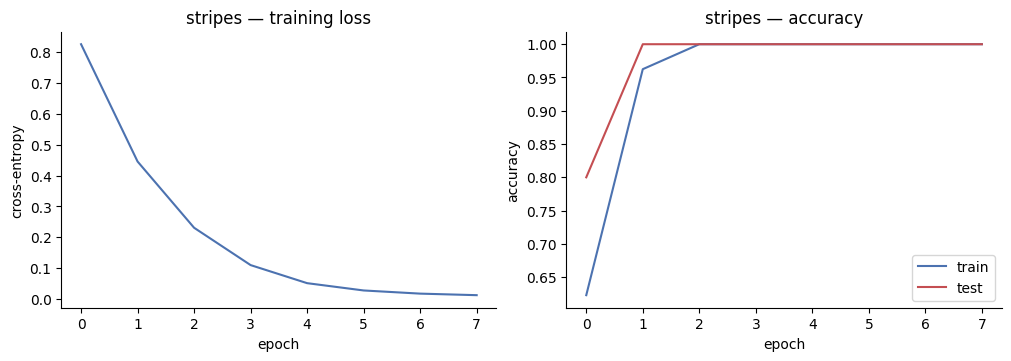

In [ ]:
fused_stripes, out_shape = build_conv_classifier(
    conv_channels=[4], in_channels=1, in_hw=16, n_classes=2, hidden=16, key=jax.random.key(1),
)
print("feature map before the classifier:", out_shape)

history_stripes = train_classifier(
    fused_stripes, X_tr_s, y_tr_s, X_te_s, y_te_s, epochs=8, batch_size=32, log_every=2,
)
plot_history(history_stripes, "stripes")

## Toy example 2: circles, squares, and crosses

A step up: three-way classification, three-channel $20\times 20$ images, and **two** stacked `conv_block`s (with pooling shrinking the spatial size in between) — the same pattern real conv nets use to build up from local edges to whole-object detectors.

train: 720  test: 180


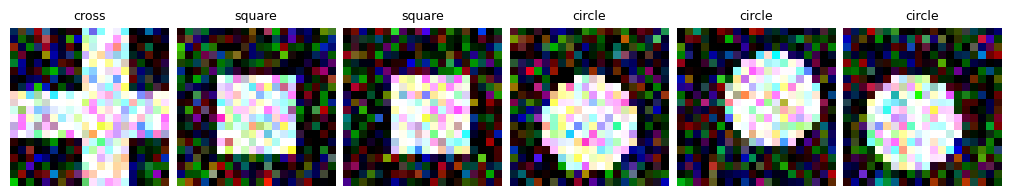

In [ ]:
def make_shapes(n_samples=900, size=20, noise=0.3, seed=0):
    rng = np.random.default_rng(seed)
    labels = rng.integers(0, 3, size=n_samples)  # 0 circle, 1 square, 2 cross
    yy, xx = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
    cy = cx = size / 2
    r = size * 0.3
    images = np.empty((n_samples, 3, size, size), dtype="float32")
    for i, cls in enumerate(labels):
        jy, jx = rng.uniform(-2.0, 2.0, size=2)
        cyi, cxi = cy + jy, cx + jx
        if cls == 0:
            mask = (yy - cyi) ** 2 + (xx - cxi) ** 2 <= r**2
        elif cls == 1:
            mask = (np.abs(yy - cyi) <= r * 0.8) & (np.abs(xx - cxi) <= r * 0.8)
        else:
            thickness = size * 0.15
            mask = (np.abs(yy - cyi) <= thickness) | (np.abs(xx - cxi) <= thickness)
        images[i] = np.broadcast_to(mask.astype("float32"), (3, size, size))
    images += rng.normal(scale=noise, size=images.shape).astype("float32")
    return images, labels.astype("int64")


X_shapes, y_shapes = make_shapes()
n_train = int(0.8 * len(X_shapes))
X_tr_sh, X_te_sh = X_shapes[:n_train], X_shapes[n_train:]
y_tr_sh, y_te_sh = y_shapes[:n_train], y_shapes[n_train:]

names = ["circle", "square", "cross"]
fig, axs = plt.subplots(1, 6, figsize=(10, 2))
for ax, img, label in zip(axs, X_shapes[:6], y_shapes[:6]):
    ax.imshow(np.clip(img.transpose(1, 2, 0), 0, 1))
    ax.set_title(names[label], fontsize=9)
    ax.axis("off")
print(f"train: {len(X_tr_sh)}  test: {len(X_te_sh)}")

feature map before the classifier: (16, 5, 5)


epoch   0 | train loss 0.813 acc 0.582 | test acc 0.694


epoch   3 | train loss 0.147 acc 0.973 | test acc 0.956


epoch   6 | train loss 0.029 acc 0.997 | test acc 0.983


epoch   9 | train loss 0.013 acc 1.000 | test acc 0.994


epoch  11 | train loss 0.010 acc 1.000 | test acc 0.994


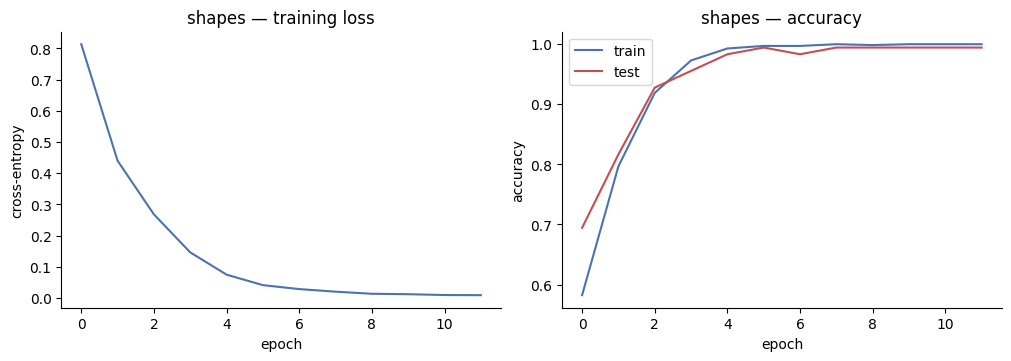

In [ ]:
fused_shapes, out_shape = build_conv_classifier(
    conv_channels=[8, 16], in_channels=3, in_hw=20, n_classes=3, hidden=32, key=jax.random.key(2),
)
print("feature map before the classifier:", out_shape)

history_shapes = train_classifier(
    fused_shapes, X_tr_sh, y_tr_sh, X_te_sh, y_te_sh, epochs=12, batch_size=32, log_every=3,
)
plot_history(history_shapes, "shapes")

## CIFAR-10: real photographs

Finally, the same recipe on real, natural images: CIFAR-10, $32\times 32$ RGB photographs across 10 classes. We download the official archive once (cached under `data/cifar10/`, outside version control) and — purely to keep this notebook's runtime short and CPU-friendly — train on a small subset for a handful of epochs, rather than the full 50,000-image / many-epoch run a full benchmark would use. The architecture itself (two `conv_block`s, max-pooling, a GELU-coupled classifier) is not toy-sized in the same way the two examples above were: scaled up to more/wider `conv_block`s and the full training set, this exact recipe reaches accuracy competitive with a backpropagation-trained equivalent of the same architecture.

train: 3000  test: 1000


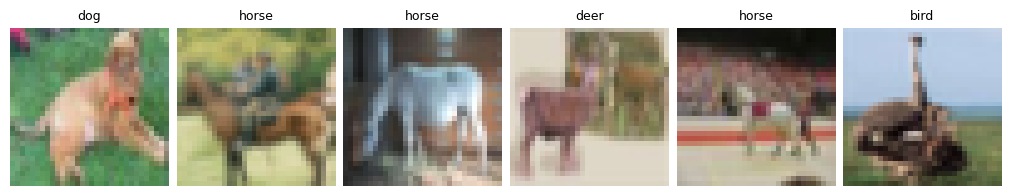

In [ ]:
CIFAR10_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
CIFAR10_DIR = os.path.join("..", "..", "..", "data", "cifar10")
CIFAR10_MEAN = np.array([0.4914, 0.4822, 0.4465], dtype="float32")
CIFAR10_STD = np.array([0.2023, 0.1994, 0.2010], dtype="float32")
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]


def _download(url, dest):
    if os.path.exists(dest):
        return
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    print(f"Downloading {url} ...")
    tmp = dest + ".part"
    urllib.request.urlretrieve(url, tmp)
    os.replace(tmp, dest)


def _load_batch(path):
    with open(path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    images = batch[b"data"].reshape(-1, 3, 32, 32).astype("float32") / 255.0
    images = (images - CIFAR10_MEAN[None, :, None, None]) / CIFAR10_STD[None, :, None, None]
    labels = np.array(batch[b"labels"], dtype="int64")
    return images, labels


def load_cifar10(data_dir, n_train=3000, n_test=1000, seed=0):
    archive = os.path.join(data_dir, "cifar-10-python.tar.gz")
    extracted = os.path.join(data_dir, "cifar-10-batches-py")
    _download(CIFAR10_URL, archive)
    if not os.path.isdir(extracted):
        print("Extracting...")
        with tarfile.open(archive) as tf:
            tf.extractall(data_dir)
    X_tr, y_tr = _load_batch(os.path.join(extracted, "data_batch_1"))
    X_te, y_te = _load_batch(os.path.join(extracted, "test_batch"))
    rng = np.random.default_rng(seed)
    idx_tr = rng.choice(len(X_tr), size=n_train, replace=False)
    idx_te = rng.choice(len(X_te), size=n_test, replace=False)
    return X_tr[idx_tr], y_tr[idx_tr], X_te[idx_te], y_te[idx_te]


X_tr_c, y_tr_c, X_te_c, y_te_c = load_cifar10(CIFAR10_DIR)
print(f"train: {len(X_tr_c)}  test: {len(X_te_c)}")

fig, axs = plt.subplots(1, 6, figsize=(10, 2))
for ax, img, label in zip(axs, X_tr_c[:6], y_tr_c[:6]):
    shown = np.clip(img.transpose(1, 2, 0) * CIFAR10_STD + CIFAR10_MEAN, 0, 1)
    ax.imshow(shown)
    ax.set_title(CLASS_NAMES[label], fontsize=9)
    ax.axis("off")

feature map before the classifier: (32, 8, 8)


epoch   0 | train loss 2.179 acc 0.257 | test acc 0.347


epoch   2 | train loss 1.367 acc 0.523 | test acc 0.442


epoch   4 | train loss 1.001 acc 0.664 | test acc 0.473


epoch   6 | train loss 0.713 acc 0.772 | test acc 0.482


epoch   8 | train loss 0.514 acc 0.844 | test acc 0.480


epoch   9 | train loss 0.408 acc 0.884 | test acc 0.495
total training time: 16.7s


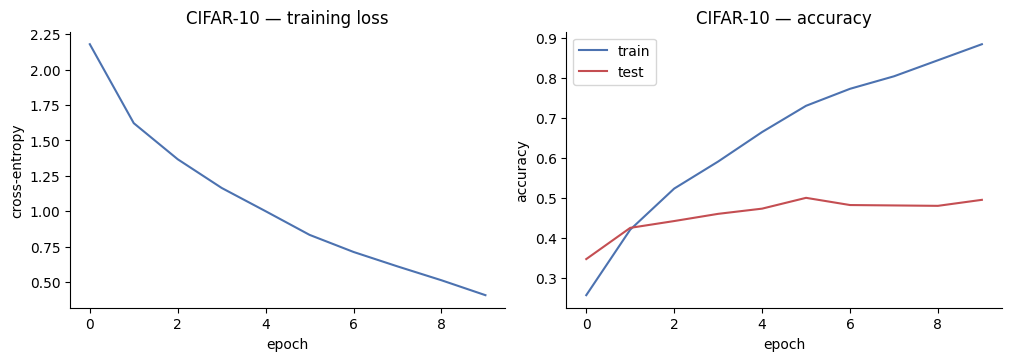

In [ ]:
fused_cifar, out_shape = build_conv_classifier(
    conv_channels=[16, 32], in_channels=3, in_hw=32, n_classes=10, hidden=64, key=jax.random.key(3),
)
print("feature map before the classifier:", out_shape)

t0 = time.time()
history_cifar = train_classifier(
    fused_cifar, X_tr_c, y_tr_c, X_te_c, y_te_c, epochs=10, batch_size=64, log_every=2,
)
print(f"total training time: {time.time() - t0:.1f}s")
plot_history(history_cifar, "CIFAR-10")

Even this reduced-scale run — a fraction of the data, two small `conv_block`s, and a few epochs — climbs well above the 10% chance level, using nothing but the local, precision-weighted belief updates from earlier notebooks. The building blocks used here (`im2col_adapter`, `conv_block`, `from_conv` for transplanting externally-trained kernels) scale directly to deeper, wider architectures and the full training set for higher accuracy, at a proportional compute cost.

## Next steps

- `tests/test_conv.py` has the full parity proofs this notebook only demonstrated informally: the hand-derived `im2col`/pooling backward formulas checked against `jax.vjp`, and one training step checked against `jax.grad` of an equivalent plain-JAX convolution.
- `pyhgf.model.transplant.from_conv` builds the same two-layer kernel network from externally-trained `(out_channels, in_channels, k_h, k_w)` weights, for comparing against or continuing to train a model trained elsewhere.
- `conv_block`'s `pool_kind` (`"avg"`/`"max"`), `strides`, and `padding` (`"SAME"`/`"VALID"`/explicit) parameters cover the usual convolutional-architecture design space; stacking more/wider blocks follows the same pattern used for the two-block examples above.

# System configuration

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pyhgf,jax,jaxlib

Last updated: Tue, 04 Aug 2026

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.13.0

pyhgf : 0.3.0
jax   : 0.11.0
jaxlib: 0.11.0

IPython   : 9.13.0
jax       : 0.11.0
matplotlib: 3.10.9
numpy     : 2.5.1
optax     : 0.2.8
pyhgf     : 0.3.0
seaborn   : 0.13.2

Watermark: 2.6.0

